Open a reduced/processed X-shooter spectrum from the pre-canned data archive pipeline (the science product you can download) and make a plot from it. This should be kind of straight-forward.

In [1]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
import sys
from astropy.io import fits
from glob import glob
from astropy.time import Time
from astropy import coordinates as coords
from astropy import units as u
from astropy import constants as const
from astropy import convolution as conv
from astropy.table import Table, Column

import spec_plot_tools as spt
import plot_spec as ps


all_avg


Now we have to put the X-shooter spectra somewhere and get them

In [2]:
target_dir='/Users/BenKaiser/Desktop/Xshooter/LHS_2534_Xshooter_data/'

In [3]:
#target_file='ADP.2019-02-12T14.14.28.768.fits'
target_file='ADP.2019-02-12T14.14.29.026.fits'
target_file=target_dir+target_file

In [4]:
hdu=fits.open(target_file)

In [5]:
print(hdu)

[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x7ff9a40bbe10>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7ff9a416b438>]


In [6]:
header=fits.getheader(target_file)

In [7]:
spectrum_table=hdu[0].data


In [8]:
print(spectrum_table)

None


In [9]:
for thing in hdu:
    print(thing)

In [10]:
waves=hdu[1].data.field('WAVE')*10.
flux=hdu[1].data.field('FLUX')

In [11]:
print(waves.shape)

(1, 18455)


In [12]:
target_spec=np.vstack([waves[0],flux[0]])
print(target_spec.shape)

(2, 18455)




wavelength-based norm range selected [10000, 11000]



ADP.2019-02-12T14.14.29.026.fits smoothed normed[10000, 11000]
Telluric Absorption smoothed


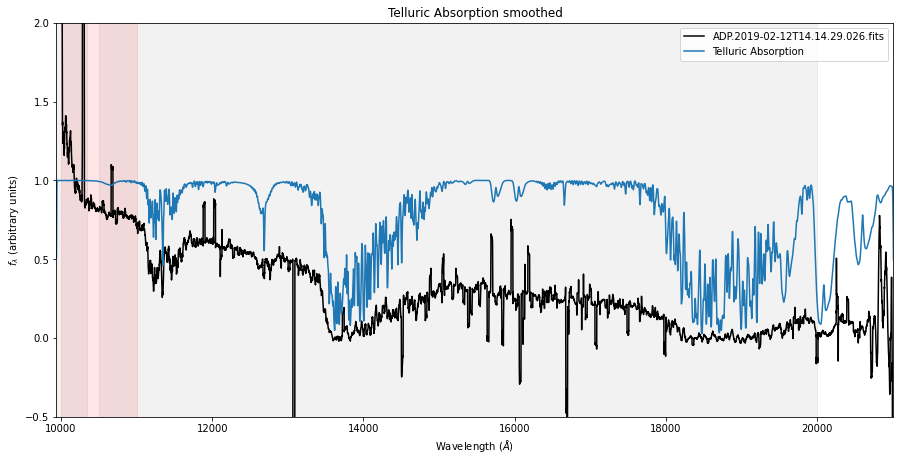

In [13]:
plt.figure(figsize=(15, 7.25))
ps.plot_spectrum(target_spec, target_file.split('/')[-1], header, norm=True, smooth=True, kernel_type='box', pix_width=40, color='k',norm_range=[10000,11000])
#plt.ylim([-2e-16,1e-16])
ps.plot_telluric_spectrum([np.nanmin(waves),np.nanmax(waves)],smooth=True,pix_width=20)
plt.ylim([-0.5,2])
spt.show_plot()



wavelength-based norm range selected [10000, 11000]



ADP.2019-02-12T14.14.29.026.fits smoothed normed[10000, 11000]
Telluric Absorption smoothed


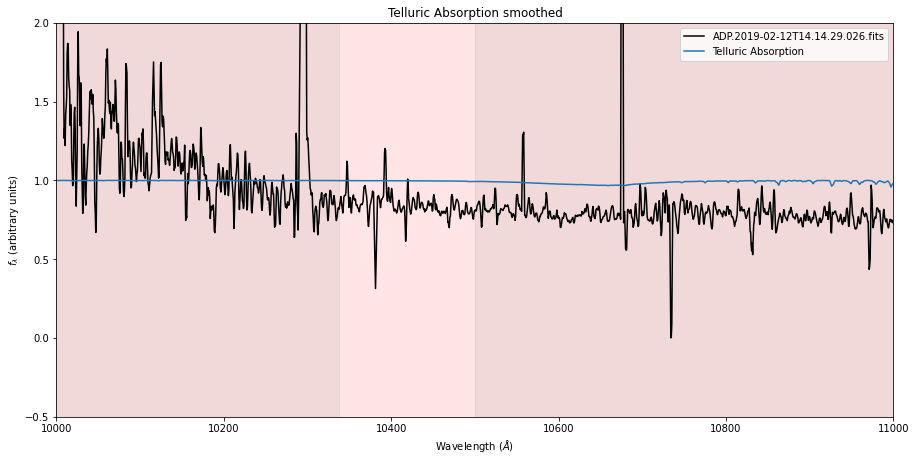

In [18]:
plt.figure(figsize=(15, 7.25))
ps.plot_spectrum(target_spec, target_file.split('/')[-1], header, norm=True, smooth=True, kernel_type='box', pix_width=4, color='k',norm_range=[10000,11000])
#plt.ylim([-2e-16,1e-16])
ps.plot_telluric_spectrum([np.nanmin(waves),np.nanmax(waves)],smooth=True,pix_width=5)
plt.ylim([-0.5,2])
plt.xlim([10000,11000])
spt.show_plot()



wavelength-based norm range selected [14500, 18000]



ADP.2019-02-12T14.14.29.026.fits smoothed normed[14500, 18000]
Telluric Absorption smoothed


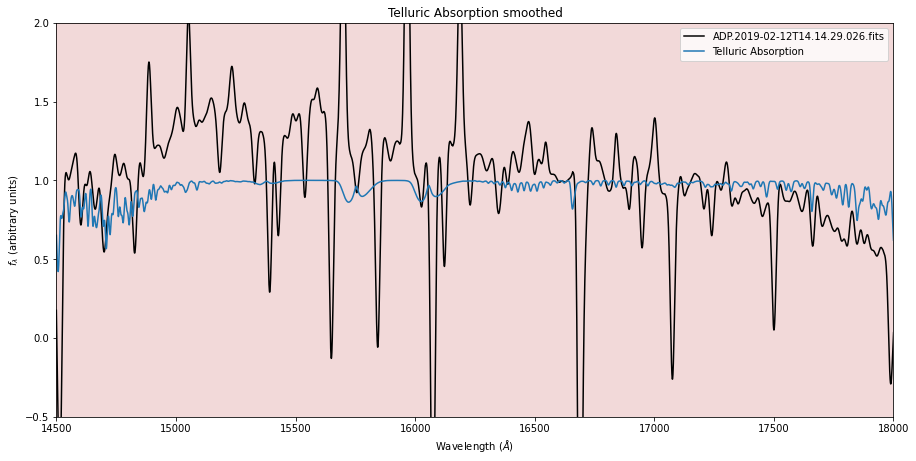

In [30]:
plt.figure(figsize=(15, 7.25))
ps.plot_spectrum(target_spec, target_file.split('/')[-1], header, norm=True, smooth=True, kernel_type='gaussian', pix_width=15, color='k',norm_range=[14500,18000],kernel_width=100)
#plt.ylim([-2e-16,1e-16])
ps.plot_telluric_spectrum([np.nanmin(waves),np.nanmax(waves)],smooth=True,pix_width=15)
plt.ylim([-0.5,2])
plt.xlim([14500,18000])
spt.show_plot()